# 两阶段超参数调优

**第一阶段**: LogisticRegression + DecisionTree — `GridSearchCV` + `TimeSeriesSplit` 穷举

**第二阶段**: RandomForest + XGBoost + LightGBM + CatBoost
- 粗搜: `RandomizedSearchCV` + `TimeSeriesSplit`
- 精搜: 3 关键参数 × 3 候选 = ≤27 组合, `GridSearchCV` + `TimeSeriesSplit`

**划分方式**: 仅时序划分 (80/20)

In [ ]:
import sys
from pathlib import Path

PROJ = Path.cwd().parent
sys.path.insert(0, str(PROJ / "src"))
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from logistics_delay.data.loader import load_processed
from logistics_delay.models.tuning import (
    compute_and_print_spw,
    run_grid_search,
    run_two_stage_search,
    save_tuning_results,
    lr_params_group,
    dt_params,
    rf_params,
    xgb_params,
    lgbm_params,
    cb_params,
    RF_KEY_PARAMS,
    XGB_KEY_PARAMS,
    LGBM_KEY_PARAMS,
    CB_KEY_PARAMS,
)
from logistics_delay.models.train import temporal_split
from logistics_delay.features.engineering import FEATURES_XGB, XGB_CAT_COLS
from logistics_delay.utils.paths import TABLES_DIR, SEED

import warnings
warnings.filterwarnings("ignore")

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

---
## 1. 数据加载

In [ ]:
df = load_processed()
print(f"\n数据形状: {df.shape}")
print(df.columns.tolist())
print(f"延误率: {df['Answer'].mean() * 100:.2f}%")

---
## 2. 时序划分 + 样本分布分析

In [3]:
# 时序划分 (80/20) — 分别获取 enc 和 xgb 两套特征
X_train_enc, X_test_enc, y_train, y_test, spw_t, cutoff = temporal_split(df, "enc")
X_train_xgb, X_test_xgb, _, _, _, _ = temporal_split(df, "xgb")

# 样本分布分析 + 动态生成 scale_pos_weight 候选值
spw_t, spw_candidates = compute_and_print_spw(y_train)

[train] 时序划分: 分割点 2020-08-08
[train] 训练: 5483 条, 2019-03-18 ~ 2020-08-08
[train] 测试: 1371 条, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818
[train] 时序划分: 分割点 2020-08-08
[train] 训练: 5483 条, 2019-03-18 ~ 2020-08-08
[train] 测试: 1371 条, 2020-08-08 ~ 2020-12-03
[train] scale_pos_weight = 0.3818
  样本分布与 scale_pos_weight 计算

训练集样本分布:
  总样本: 5483
  正样本 (延误): 3968 (72.37%)
  负样本 (准时): 1515 (27.63%)
  spw_t (负/正) = 0.3818

TimeSeriesSplit(5 folds) 各 fold 延误率:
  Fold   训练延误率          验证延误率          验证正样本比
  ------------------------------------------------------
  Fold 0   0.87        %  87.95       %  87.95%
  Fold 1   44.29       %  98.69       %  98.69%
  Fold 2   62.39       %  98.58       %  98.58%
  Fold 3   71.42       %  79.08       %  79.08%
  Fold 4   72.95       %  69.44       %  69.44%

动态生成的 scale_pos_weight 候选值:
  0.1909, 0.2864, 0.3818, 0.4773, 0.5727
  生成规则: [spw_t×0.5, spw_t×0.75, spw_t×1.0, spw_t×1.25, spw_t×1.5]


---
## 3. 第一阶段 — GridSearchCV 穷举

In [4]:
print("=" * 60)
print("  第一阶段: GridSearchCV 穷举")
print("=" * 60)

lr_result = run_grid_search(
    LogisticRegression(max_iter=1000, random_state=SEED),
    lr_params_group,
    X_train_enc, y_train, X_test_enc, y_test,
)

dt_result = run_grid_search(
    DecisionTreeClassifier(random_state=SEED),
    dt_params,
    X_train_enc, y_train, X_test_enc, y_test,
)

  第一阶段: GridSearchCV 穷举

  GridSearch: LogisticRegression
  CV AUC  = 61.54%
  Test AUC = 91.57%
  Test F1  = 0.7181

  GridSearch: DecisionTreeClassifier
  CV AUC  = 63.15%
  Test AUC = 85.09%
  Test F1  = 0.4048


---
## 4. 第二阶段 — 随机搜索 → 精细网格

In [5]:
print("=" * 60)
print("  第二阶段: 两阶段搜索 (粗搜 → 精搜)")
print("=" * 60)

rf_result = run_two_stage_search(
    model=RandomForestClassifier(random_state=SEED),
    param_dist=rf_params,
    key_params=RF_KEY_PARAMS,
    n_iter=30,
    X_train=X_train_enc,
    y_train=y_train,
    X_test=X_test_enc,
    y_test=y_test,
)

xgb_params_local = {**xgb_params, "scale_pos_weight": spw_candidates}
xgb_result = run_two_stage_search(
    model=XGBClassifier(random_state=SEED, verbosity=0, enable_categorical=True),
    param_dist=xgb_params_local,
    key_params=XGB_KEY_PARAMS,
    n_iter=40,
    X_train=X_train_xgb,
    y_train=y_train,
    X_test=X_test_xgb,
    y_test=y_test,
)

from lightgbm import LGBMClassifier
lgbm_result = run_two_stage_search(
    model=LGBMClassifier(random_state=SEED, verbose=-1),
    param_dist=lgbm_params,
    key_params=LGBM_KEY_PARAMS,
    n_iter=40,
    X_train=X_train_xgb,
    y_train=y_train,
    X_test=X_test_xgb,
    y_test=y_test,
)

cat_feats = [c for c in XGB_CAT_COLS if c in FEATURES_XGB]
cb_result = run_two_stage_search(
    model=CatBoostClassifier(random_seed=SEED, verbose=0, iterations=200),
    param_dist=cb_params,
    key_params=CB_KEY_PARAMS,
    n_iter=20,
    X_train=X_train_xgb,
    y_train=y_train,
    X_test=X_test_xgb,
    y_test=y_test,
    fit_params={"cat_features": cat_feats},
)

  第二阶段: 两阶段搜索 (粗搜 → 精搜)

  阶段 1/2 — 随机搜索: RandomForestClassifier (n_iter=30)
  [粗搜] 最佳 CV AUC = 61.24%
    n_estimators: 100
    min_samples_split: 10
    min_samples_leaf: 1
    max_features: None
    max_depth: 10
    class_weight: None
    bootstrap: True

  阶段 2/2 — 精细网格搜索: RandomForestClassifier
  精细网格 3 关键参数 × 27 种组合:
    n_estimators: [50, 100, 200]
    max_depth: [7, 10, 15]
    min_samples_leaf: [1, 2, 5]
    min_samples_split: 固定为 10
    max_features: 固定为 None
    class_weight: 固定为 None
    bootstrap: 固定为 True
  [精搜] 最佳 CV AUC = 61.73%

  ✅ RandomForestClassifier 完成
     CV AUC  = 61.73%
     Test AUC = 85.10%
     Test F1  = 0.5100

  阶段 1/2 — 随机搜索: XGBClassifier (n_iter=40)
  [粗搜] 最佳 CV AUC = 66.44%
    subsample: 0.6
    scale_pos_weight: 0.5727066532258064
    reg_lambda: 0.1
    reg_alpha: 1
    n_estimators: 500
    min_child_weight: 3
    max_depth: 8
    learning_rate: 0.01
    gamma: 1
    colsample_bytree: 1.0

  阶段 2/2 — 精细网格搜索: XGBClassifier
  精细网格 3 关键参数 × 27 种组合

---
## 5. 结果汇总

In [6]:
# 收集所有结果
results = pd.DataFrame([
    lr_result, dt_result, rf_result,
    xgb_result, lgbm_result, cb_result,
])

# 显示汇总表
summary = results[["model", "cv_auc", "test_auc", "test_f1"]].copy()
summary["cv_auc"] = summary["cv_auc"] * 100
summary["test_auc"] = summary["test_auc"] * 100
summary.columns = ["模型", "CV AUC(%)", "Test AUC(%)", "Test F1"]
print("=" * 60)
print("  调参结果汇总")
print("=" * 60)
print(summary.to_string(index=False))

  调参结果汇总
                    模型  CV AUC(%)  Test AUC(%)  Test F1
    LogisticRegression  61.544903    91.572516 0.718093
DecisionTreeClassifier  63.151974    85.089532 0.404776
RandomForestClassifier  61.733155    85.101420 0.509985
         XGBClassifier  69.145330    83.356154 0.664975
        LGBMClassifier  61.714364    89.469779 0.692049
    CatBoostClassifier  74.815667    88.355416 0.771574


---
## 6. 最佳参数详情

In [7]:
print("=" * 60)
print("  各模型最佳参数")
print("=" * 60)
for _, row in results.iterrows():
    print(f"\n>>> {row['model']}")
    print(f"    CV AUC  = {row['cv_auc'] * 100:.2f}%")
    print(f"    Test AUC = {row['test_auc'] * 100:.2f}%")
    print(f"    Test F1  = {row['test_f1']:.4f}")
    if isinstance(row['best_params'], dict):
        for k, v in row['best_params'].items():
            print(f"      {k}: {v}")
    else:
        print(f"      best_params: {row['best_params']}")

  各模型最佳参数

>>> LogisticRegression
    CV AUC  = 61.54%
    Test AUC = 91.57%
    Test F1  = 0.7181
      C: 100
      class_weight: balanced
      max_iter: 1000
      penalty: l2
      solver: lbfgs

>>> DecisionTreeClassifier
    CV AUC  = 63.15%
    Test AUC = 85.09%
    Test F1  = 0.4048
      class_weight: None
      criterion: entropy
      max_depth: 4
      min_samples_leaf: 50
      min_samples_split: 10

>>> RandomForestClassifier
    CV AUC  = 61.73%
    Test AUC = 85.10%
    Test F1  = 0.5100
      bootstrap: True
      class_weight: None
      max_depth: 7
      max_features: None
      min_samples_leaf: 1
      min_samples_split: 10
      n_estimators: 200

>>> XGBClassifier
    CV AUC  = 69.15%
    Test AUC = 83.36%
    Test F1  = 0.6650
      colsample_bytree: 1.0
      gamma: 1
      learning_rate: 0.01
      max_depth: 10
      min_child_weight: 3
      n_estimators: 300
      reg_alpha: 1
      reg_lambda: 0.1
      scale_pos_weight: 0.5727066532258064
      subsampl

---
## 7. 保存结果

In [8]:
save_tuning_results(results, TABLES_DIR)
print("\n全部完成。")


[OK] 调参结果 → C:\Users\a\Desktop\Technische Universiteit Eindhoven\Logistics_Delay_Project\outputs\tables\tuning_results.csv

全部完成。


---
## 8. 默认参数 vs 调优最优参数对比

对比基线（默认参数来自 `evaluate.py` 的 `get_model()`）与调优后的最优参数在各模型的 AUC 和 F1 表现。

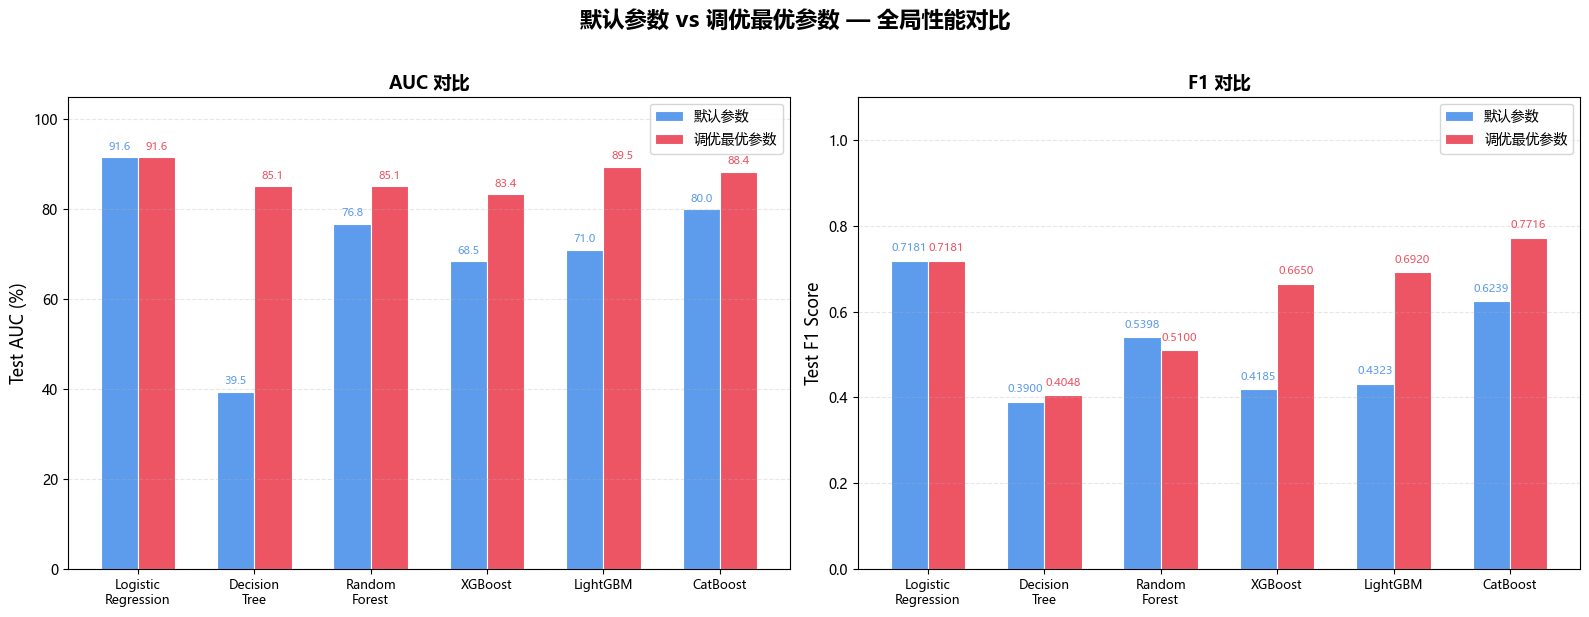

图片已保存: outputs/figures/models/default_vs_tuned_comparison.png


In [ ]:
# ═══════════════════════════════════════════════
#  默认参数 vs 调优参数 — AUC 对比图 + 参数对比表
# ═══════════════════════════════════════════════

# ── 1. 性能数据 ──────────────────────────────────
default_perf = {
    "LogisticRegression": {"auc": 91.59, "f1": 0.7181},
    "DecisionTree":       {"auc": 39.46, "f1": 0.3900},
    "RandomForest":       {"auc": 76.77, "f1": 0.5398},
    "XGBoost":            {"auc": 68.47, "f1": 0.4185},
    "LightGBM":           {"auc": 71.03, "f1": 0.4323},
    "CatBoost":           {"auc": 80.04, "f1": 0.6239},
}

tuned_perf = {
    "LogisticRegression": {"auc": 91.57, "f1": 0.7181},
    "DecisionTree":       {"auc": 85.09, "f1": 0.4048},
    "RandomForest":       {"auc": 85.10, "f1": 0.5100},
    "XGBoost":            {"auc": 83.36, "f1": 0.6650},
    "LightGBM":           {"auc": 89.47, "f1": 0.6920},
    "CatBoost":           {"auc": 88.36, "f1": 0.7716},
}

model_names = ["LogisticRegression", "DecisionTree", "RandomForest",
               "XGBoost", "LightGBM", "CatBoost"]
model_labels = ["Logistic\nRegression", "Decision\nTree", "Random\nForest",
                "XGBoost", "LightGBM", "CatBoost"]

default_aucs = [default_perf[m]["auc"] for m in model_names]
tuned_aucs   = [tuned_perf[m]["auc"] for m in model_names]
default_f1s  = [default_perf[m]["f1"] for m in model_names]
tuned_f1s    = [tuned_perf[m]["f1"] for m in model_names]

# ── 2. 绘图：全局 AUC 对比 ────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("默认参数 vs 调优最优参数 — 全局性能对比", fontsize=16, fontweight="bold", y=1.02)

x = np.arange(len(model_names))
w = 0.32

colors_default = "#5D9CEC"
colors_tuned   = "#ED5565"

# —— 左图: AUC ——
bars1_d = ax1.bar(x - w/2, default_aucs, w, label="默认参数",
                  color=colors_default, edgecolor="white", linewidth=0.8)
bars1_t = ax1.bar(x + w/2, tuned_aucs, w, label="调优最优参数",
                  color=colors_tuned, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars1_d, default_aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}", ha="center", va="bottom", fontsize=8, color=colors_default)
for bar, val in zip(bars1_t, tuned_aucs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{val:.1f}", ha="center", va="bottom", fontsize=8, color=colors_tuned)

ax1.set_xticks(x)
ax1.set_xticklabels(model_labels, fontsize=9)
ax1.set_ylabel("Test AUC (%)", fontsize=12)
ax1.set_title("AUC 对比", fontsize=13, fontweight="bold")
ax1.legend(fontsize=10)
ax1.grid(axis="y", linestyle="--", alpha=0.3)
ax1.set_ylim(0, 105)

# —— 右图: F1 ——
bars2_d = ax2.bar(x - w/2, default_f1s, w, label="默认参数",
                  color=colors_default, edgecolor="white", linewidth=0.8)
bars2_t = ax2.bar(x + w/2, tuned_f1s, w, label="调优最优参数",
                  color=colors_tuned, edgecolor="white", linewidth=0.8)

for bar, val in zip(bars2_d, default_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, color=colors_default)
for bar, val in zip(bars2_t, tuned_f1s):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.015,
             f"{val:.4f}", ha="center", va="bottom", fontsize=8, color=colors_tuned)

ax2.set_xticks(x)
ax2.set_xticklabels(model_labels, fontsize=9)
ax2.set_ylabel("Test F1 Score", fontsize=12)
ax2.set_title("F1 对比", fontsize=13, fontweight="bold")
ax2.legend(fontsize=10)
ax2.grid(axis="y", linestyle="--", alpha=0.3)
ax2.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(Path.cwd().parent / "outputs" / "figures" / "models" / "default_vs_tuned_comparison.png",
            dpi=300, bbox_inches="tight")
plt.show()
print("图片已保存: outputs/figures/models/default_vs_tuned_comparison.png")

In [ ]:
# ── 3. 参数对比表（终端打印）─────────────────────

# 默认参数
default_params_tbl = {
    "LogisticRegression": "max_iter=1000, class_weight='balanced'",
    "DecisionTree":       "class_weight='balanced', max_depth=8",
    "RandomForest":       "n_estimators=100, class_weight='balanced'",
    "XGBoost":            "n_estimators=200, scale_pos_weight=spw",
    "LightGBM":           "n_estimators=200, scale_pos_weight=spw",
    "CatBoost":           "iterations=200, class_weights={0:1.0, 1:spw}",
}

# 调优最优参数（简短描述）
tuned_params_tbl = {
    "LogisticRegression": "C=100, penalty=l2, solver=lbfgs, class_weight='balanced'",
    "DecisionTree":       "max_depth=4, min_samples_leaf=50, criterion=entropy",
    "RandomForest":       "n_estimators=200, max_depth=7, min_samples_leaf=1",
    "XGBoost":            "lr=0.01, max_depth=10, n_est=300, subsample=0.6, spw=0.573",
    "LightGBM":           "lr=0.03, num_leaves=31, n_est=100, subsample=0.6",
    "CatBoost":           "lr=0.05, depth=8, iter=100, l2_leaf_reg=5",
}

# 计算 AUC 提升
auc_deltas = {}
for m in model_names:
    delta = round(tuned_perf[m]["auc"] - default_perf[m]["auc"], 2)
    auc_deltas[m] = f"+{delta:.2f}" if delta >= 0 else f"{delta:.2f}"

# 打印对比表
print("=" * 140)
print(f"{'模型':<22s} {'指标':>10s} {'默认参数 AUC':>14s} {'调优 AUC':>14s} {'ΔAUC':>8s} {'默认参数':>48s} {'调优最优参数'}")
print("=" * 140)

for m in model_names:
    label = m.replace("Regression","").replace("Tree","").replace("Forest","")
    d_auc = default_perf[m]["auc"]
    t_auc = tuned_perf[m]["auc"]
    d_f1  = default_perf[m]["f1"]
    t_f1  = tuned_perf[m]["f1"]

    # AUC 行
    print(f"{m:<22s} {'AUC(%)':>10s} {d_auc:>13.2f}% {t_auc:>13.2f}% {auc_deltas[m]:>8s} "
          f"{default_params_tbl[m]:<48s} {tuned_params_tbl[m]}")
    # F1 行
    print(f"{'':22s} {'F1':>10s} {d_f1:>13.4f} {t_f1:>13.4f} "
          f"{'+' if t_f1 >= d_f1 else ''}{t_f1 - d_f1:>+7.4f} "
          f"{'':48s} {'':s}")
    print("-" * 140)

print("=" * 140)


模型                             指标       默认参数 AUC         调优 AUC     ΔAUC                                             默认参数 调优最优参数
LogisticRegression         AUC(%)         91.59%         91.57%    -0.02 max_iter=1000, class_weight='balanced'           C=100, penalty=l2, solver=lbfgs, class_weight='balanced'
                               F1        0.7181        0.7181 ++0.0000                                                  
--------------------------------------------------------------------------------------------------------------------------------------------
DecisionTree               AUC(%)         39.46%         85.09%   +45.63 class_weight='balanced', max_depth=8             max_depth=4, min_samples_leaf=50, criterion=entropy
                               F1        0.3900        0.4048 ++0.0148                                                  
---------------------------------------------------------------------------------------------------------------------------------------